#  NYC HVFHV Taxi Demand-Supply Imbalance Prediction

**Project**: Predict demand-supply imbalance for driver reallocation  
**Data**: NYC High Volume FHV (HVFHV) trip records 2024–2025 (Parquet)  
**Aggregation**: 60-minute sliding window, sliding every 15 minutes  
**Grain**: (zone_id, window_end)

---
## Section 1 — Setup

In [1]:
# ─── Standard Library ────────────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings('ignore')

# ─── PySpark ─────────────────────────────────────────────────────────────────
from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.sql.functions import count, when, col


# ─── Data / ML ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import lightgbm as lgb

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_squared_error, r2_score
)
from sklearn.preprocessing import label_binarize

# ─── Visualisation ────────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

matplotlib.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})
PALETTE = sns.color_palette('tab10')

print('All imports OK')

All imports OK


In [2]:
# ─── Spark Session ────────────────────────────────────────────────────────────
spark = (
    SparkSession.builder
    .appName('NYC_HVFHV_Demand_Supply')

    # Core
    .master("local[*]")

    # Memory (quan trọng)
    .config("spark.driver.memory", "8g")
    .config("spark.driver.maxResultSize", "4g")

    # Shuffle tuning (RẤT QUAN TRỌNG)
    .config("spark.sql.shuffle.partitions", "64")

    # Adaptive Query Execution
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")

    # Parquet handling
    .config("spark.sql.parquet.mergeSchema", "false")
    .config("spark.sql.parquet.filterPushdown", "true")

    # Timezone
    .config("spark.sql.session.timeZone", "America/New_York")

    .getOrCreate()
)
spark.sparkContext.setLogLevel('WARN')
print(f'Spark version: {spark.version}')

Spark version: 3.5.7


In [34]:
BRONZE_PATH = 'datasets/fvhfv/*'
schema = StructType([
    StructField("hvfhs_license_num", StringType(), True),
    StructField("dispatching_base_num", StringType(), True),
    StructField("originating_base_num", StringType(), True),
    StructField("PULocationID", IntegerType(), True),
    StructField("DOLocationID", IntegerType(), True),
    StructField("request_datetime", TimestampNTZType(), True),
    StructField("pickup_datetime", TimestampNTZType(), True),
    StructField("dropoff_datetime", TimestampNTZType(), True),
    StructField("trip_miles", DoubleType(), True),
    StructField("trip_time", LongType(), True),
    StructField("base_passenger_fare", DoubleType(), True),
    StructField("driver_pay", DoubleType(), True),
    StructField("tips", DoubleType(), True),
    StructField("congestion_surcharge", DoubleType(), True),
    StructField("airport_fee", DoubleType(), True),
    StructField("tolls", DoubleType(), True),
    StructField("bcf", DoubleType(), True),
    StructField("sales_tax", DoubleType(), True),
    StructField("shared_match_flag", StringType(), True),
    StructField("shared_request_flag", StringType(), True),
    StructField("on_scene_datetime", TimestampNTZType(), True),
    StructField("access_a_ride_flag", StringType(), True),
    StructField("wav_request_flag", StringType(), True),
    StructField("wav_match_flag", StringType(), True),
    StructField("cbd_congestion_fee", DoubleType(), True)

])
df = (
    spark.read
    .schema(schema)
    .parquet(BRONZE_PATH)
)
df.count(), len(df.columns)

Py4JJavaError: An error occurred while calling o1139.count.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 11 in stage 405.0 failed 1 times, most recent failure: Lost task 11.0 in stage 405.0 (TID 4108) (menhera-chan executor driver): java.io.FileNotFoundException: C:\Users\Nitro Tiger\AppData\Local\Temp\blockmgr-13446293-3fec-405a-9833-ae37a7207955\2b\temp_shuffle_9b1c6799-9a57-42f8-af2c-4a9d6973d913 (The system cannot find the path specified)
	at java.base/java.io.FileOutputStream.open0(Native Method)
	at java.base/java.io.FileOutputStream.open(FileOutputStream.java:293)
	at java.base/java.io.FileOutputStream.<init>(FileOutputStream.java:235)
	at org.apache.spark.storage.DiskBlockObjectWriter.initialize(DiskBlockObjectWriter.scala:147)
	at org.apache.spark.storage.DiskBlockObjectWriter.open(DiskBlockObjectWriter.scala:167)
	at org.apache.spark.storage.DiskBlockObjectWriter.write(DiskBlockObjectWriter.scala:330)
	at org.apache.spark.shuffle.sort.Bypas

In [4]:
trip = df.select(
    col("PULocationID").cast("long"),
    col("DOLocationID").cast("long"),
    col("request_datetime"),
    col("pickup_datetime"),
    col("dropoff_datetime"),
    col("trip_miles").cast("double"),
    col("trip_time").cast("long"),
    col("base_passenger_fare").cast("double"),
    col("driver_pay").cast("double"),
    col("tips").cast("double"),
    col("congestion_surcharge").cast("double"),
    col("airport_fee").cast("double"),
    col("tolls").cast("double"),
    col("bcf").cast("double"),
    col("sales_tax").cast("double"),
    col("shared_match_flag").alias("share_match_flag"),
    col("shared_request_flag").alias("share_request_flag"),
    col("wav_request_flag"),
    col("access_a_ride_flag"),
    col("wav_match_flag"),
    col("hvfhs_license_num"),
    col("cbd_congestion_fee")
)

In [5]:
null_stats = trip.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in trip.columns
])

# null_stats.show()

In [6]:
# trip.describe().show()

In [7]:
# trip.groupby("wav_match_flag") \
#     .count().show()

In [8]:
# trip.where("tips ==0").show(10, truncate=False)
# trip.where("tips ==0").count()

In [9]:
schemas = {}

for f in trip.inputFiles():
    df = spark.read.parquet(f)
    schemas[f] = df.schema.simpleString()

# group theo schema
from collections import defaultdict

groups = defaultdict(list)

for f, s in schemas.items():
    groups[s].append(f)

print(f"Total different schemas: {len(groups)}")

for i, (schema, files) in enumerate(groups.items()):
    print(f"\n--- Schema group {i+1} ({len(files)} files) ---")
    print(schema)

Total different schemas: 2

--- Schema group 1 (13 files) ---
struct<hvfhs_license_num:string,dispatching_base_num:string,originating_base_num:string,request_datetime:timestamp_ntz,on_scene_datetime:timestamp_ntz,pickup_datetime:timestamp_ntz,dropoff_datetime:timestamp_ntz,PULocationID:int,DOLocationID:int,trip_miles:double,trip_time:bigint,base_passenger_fare:double,tolls:double,bcf:double,sales_tax:double,congestion_surcharge:double,airport_fee:double,tips:double,driver_pay:double,shared_request_flag:string,shared_match_flag:string,access_a_ride_flag:string,wav_request_flag:string,wav_match_flag:string,cbd_congestion_fee:double>

--- Schema group 2 (12 files) ---
struct<hvfhs_license_num:string,dispatching_base_num:string,originating_base_num:string,request_datetime:timestamp_ntz,on_scene_datetime:timestamp_ntz,pickup_datetime:timestamp_ntz,dropoff_datetime:timestamp_ntz,PULocationID:int,DOLocationID:int,trip_miles:double,trip_time:bigint,base_passenger_fare:double,tolls:double,bcf:d

## Section 1.5 -- Clean data

In [10]:
trips = trip.where("base_passenger_fare > 0 and driver_pay > 0 and trip_miles < 500 and trip_time < 20000 and driver_pay < 1500 and pickup_datetime > request_datetime ")
# trips.count()

In [11]:
# trips = trips.dropDuplicates()
# trips.count()

---
## Section 2 — Feature Engineering (Spark)

In [12]:
# ─── Window Configuration ─────────────────────────────────────────────────────
WINDOW_SECONDS = 60 * 60   # 60 min in seconds
SLIDE_SECONDS  =  15 * 60   # 15 min  in seconds

def epoch_to_window_end(ts_col: str, window_s: int = WINDOW_SECONDS, slide_s: int = SLIDE_SECONDS):
    """
    Assign each timestamp to the next (future) window boundary.
    window_end = ceil(ts / slide) * slide  — snaps to the next slide boundary.
    Spark's window() function handles this natively.
    """
    return F.window(F.col(ts_col), f'{window_s} seconds', f'{slide_s} seconds')

flag = lambda c: F.when(F.col(c) == "Y", 1).otherwise(0)
is_uber = F.when(F.col("hvfhs_license_num") == "HV0003", 1).otherwise(0)
print('Window helpers defined')

Window helpers defined


In [13]:
demand = (
    trips
    .withColumn("zone_id", F.col("PULocationID"))
    .withColumn("window", epoch_to_window_end("request_datetime"))
    .groupBy("zone_id", "window")
    .agg(
        # volume
        F.count("*").alias("requests_60m"),
        F.sum(
            F.when(
                F.col("request_datetime") >= F.col("window.end") - F.expr(f"INTERVAL {SLIDE_SECONDS} seconds"),
                1
            ).otherwise(0)
        ).alias("requests_15m"),

        # WAV / AAR (request-time)
        F.sum(flag("wav_request_flag")).alias("wav_req"),
        F.sum(flag("access_a_ride_flag")).alias("aar_req"),
        F.sum(flag("share_request_flag")).alias("share_req"),

        # platform share
        F.sum(is_uber).alias("uber_req"),
    )
    .withColumn("window_end", F.col("window.end"))
    .drop("window")
).where("zone_id <= 263 and window_end <= '2026-01-31 12:00:00' and window_end >= '2025-01-05 08:00:00'")


In [14]:
pickup = (
    trips
    .withColumn("zone_id", F.col("PULocationID"))
    .withColumn("window", epoch_to_window_end("pickup_datetime"))
    .withColumn(
        "pickup_delay_s",
        F.unix_timestamp("pickup_datetime") - F.unix_timestamp("request_datetime")
    )
    .groupBy("zone_id", "window")
    .agg(
        # volume
        F.count("*").alias("pickup_60m"),
        F.sum(
            F.when(
                F.col("pickup_datetime") >= F.col("window.end") - F.expr(f"INTERVAL {SLIDE_SECONDS} seconds"),
                1
            )
        ).alias("pickup_15m"),

        # delay
        F.mean("pickup_delay_s").alias("pickup_delay_mean"),
        F.stddev("pickup_delay_s").alias("pickup_delay_std"),
        
        # matching (proxy)
        F.sum(
            F.when(col('request_datetime') >= col('window.start') , 1).otherwise(0)
        ).alias('matched_rp'),
        
        F.sum(
            F.when(((col('request_datetime') >= col('window.start') )
                   & (F.col("pickup_datetime") >= (F.col("window.end") - F.expr(f"INTERVAL {SLIDE_SECONDS} seconds")))), 1).otherwise(0)
        ).alias('matched_rp_15m'),

        # WAV match
        F.sum(flag("wav_match_flag")).alias("wav_match"),
        F.sum(flag("share_match_flag")).alias("share_match"),

    )
    .withColumn("window_end", F.col("window.end"))
    .drop("window")
).where("zone_id <= 263 and window_end <= '2026-01-31 12:00:00' and window_end >= '2025-01-05 08:00:00'")
# pickup.printSchema(), pickup.show(5, truncate=False), pickup.count()
# pickup.select(F.min("window_end"), F.max("window_end")).show()

In [15]:
dropoff_counts = (
    trips
    .withColumn("zone_id", F.col("DOLocationID"))
    .withColumn("window", epoch_to_window_end("dropoff_datetime"))
    .groupBy("zone_id", "window")
    .agg(
        F.count("*").alias("dropoff_60m"),
        F.sum(
            F.when(
                F.col("dropoff_datetime") >= F.col("window.end") - F.expr(f"INTERVAL {SLIDE_SECONDS} seconds"),
                1
            )
        ).alias("dropoff_15m"),
        
        F.sum(
            F.when(((col('request_datetime') >= col('window.start'))), 1).otherwise(0)
        ).alias('matched_rd'),
        
    )
    .withColumn("window_end", F.col("window.end"))
    .drop("window")
).where("zone_id <= 263 and window_end <= '2026-01-31 12:00:00' and window_end >= '2025-01-05 08:00:00'")
# dropoff_counts.printSchema(), dropoff_counts.show(5, truncate=False), dropoff_counts.count()
# dropoff_counts.select(F.min("window_end"), F.max("window_end")).show()

In [16]:
trips_valid = trips.filter(
    F.col("trip_miles").between(0.3, 500) &
    F.col("trip_time").between(200, 20000) &
    F.col("base_passenger_fare").between(1, 1500) &
    F.col("driver_pay").between(1, 1500)
)

dropoff_stats = (
    trips_valid
    .withColumn("zone_id", F.col("PULocationID"))
    .withColumn("window", epoch_to_window_end("dropoff_datetime"))
    .groupBy("zone_id", "window")
    .agg(
        F.mean('trip_time').alias('avg_trip_time'),
        # Price
        F.mean('base_passenger_fare').alias('avg_fare'),
        F.mean('driver_pay').alias('avg_driver_pay'),
        F.mean('tips').alias('avg_tips'),
        F.mean('bcf').alias('avg_bcf'),
        F.mean('tolls').alias('avg_tolls'),
        F.mean('congestion_surcharge').alias('avg_congestion_surcharge'),
        F.mean('airport_fee').alias('avg_airport_fee'),
        F.mean('sales_tax').alias('avg_sales_tax'),
        F.mean('cbd_congestion_fee').alias('avg_cbd_congestion_fee'),
        # Distance
        F.mean('trip_miles').alias('avg_distance'),
    )
    .withColumn("window_end", F.col("window.end"))
    .drop("window")
).where("zone_id <= 263 and window_end <= '2026-01-31 12:00:00' and window_end >= '2025-01-05 08:00:00'")
# dropoff_stats.printSchema(), dropoff_stats.show(5, truncate=False), dropoff_stats.count()
# dropoff_stats.select(F.min("window_end"), F.max("window_end")).show()

In [17]:
# ─── 2.6 Temporal Features ────────────────────────────────────────────────────

US_HOLIDAYS = [
    # ===== 2026 =====
    "2026-01-01","2026-01-15","2026-02-19","2026-05-27","2026-06-19",
    "2026-07-04","2026-09-02","2026-10-14","2026-11-11","2026-11-28","2026-12-25",

    # ===== 2025 =====
    "2025-01-01","2025-01-20","2025-02-17","2025-05-26","2025-06-19",
    "2025-07-04","2025-09-01","2025-10-13","2025-11-11","2025-11-27","2025-12-25",

    # ===== 2024 =====
    "2024-01-01","2024-01-15","2024-02-19","2024-05-27","2024-06-19",
    "2024-07-04","2024-09-02","2024-10-14","2024-11-11","2024-11-28","2024-12-25",
]

def add_temporal_features(df):

    df = df.withColumn("date", F.to_date("window_end"))

    # ===== BASIC TIME FEATURES =====
    df = (
        df
        .withColumn("hour", F.hour("window_end"))
        .withColumn("minute", F.minute("window_end"))
        .withColumn("day_of_week", F.dayofweek("window_end"))  # 1=Sun
        .withColumn("month", F.month("window_end"))
        .withColumn("week_of_year", F.weekofyear("window_end"))
        .withColumn("is_weekend", F.col("day_of_week").isin(1,7).cast("int"))
    )

    # ===== HOLIDAY =====
    df = df.withColumn(
        "is_holiday",
        F.col("date").isin(US_HOLIDAYS).cast("int")
    )

    # ===== 15-MIN SLOT =====
    df = df.withColumn(
        "slot_15m",
        F.floor(F.col("minute") / 15)   # +1 to make it 1-indexed
    )

    # ===== CYCLICAL ENCODING =====

    # 1. 15-min slot (0-4)
    df = df.withColumn(
        "slot_15m_sin",
        F.sin(2 * 3.1415926 * F.col("slot_15m") / 4)
    ).withColumn(
        "slot_15m_cos",
        F.cos(2 * 3.1415926 * F.col("slot_15m") / 4)
    )

    # 2. Day of week (1–7)
    df = df.withColumn(
        "dow_sin",
        F.sin(2 * 3.1415926 * F.col("day_of_week") / 7)
    ).withColumn(
        "dow_cos",
        F.cos(2 * 3.1415926 * F.col("day_of_week") / 7)
    )
    
    df = df.withColumn(
        "hou_sin",
        F.sin(2 * 3.1415926 * F.col("hour") / 24)
    ).withColumn(
        "hou_cos",
        F.cos(2 * 3.1415926 * F.col("hour") / 24)
    )

    # 3. Week of year (1–52)
    df = df.withColumn(
        "woy_sin",
        F.sin(2 * 3.1415926 * F.col("week_of_year") / 52)
    ).withColumn(
        "woy_cos",
        F.cos(2 * 3.1415926 * F.col("week_of_year") / 52)
    )
    
    # 4. Month (1–12)
    df = df.withColumn(
        "mon_sin",
        F.sin(2 * 3.1415926 * F.col("month") / 12)
    ).withColumn(
        "mon_cos",
        F.cos(2 * 3.1415926 * F.col("month") / 12)
    )
    
    return df.drop("date", "slot_15m", "hour", "minute", "day_of_week", "month", "week_of_year", "year")  # drop intermediate columns

print('Temporal feature helper defined')

Temporal feature helper defined


In [18]:
# ─── 2.7 Spatial Feature: Neighbor Requests ───────────────────────────────────
# neighbor_requests_60m = sum of requests from adjacent zones in the same window
# We use the TLC taxi zone adjacency list (simplified as a broadcast dictionary).

# !! Replace with actual adjacency data from TLC zone shapefile if available !!
# Below is a small example; in production load the full 263-zone adjacency map.
ZONE_NEIGHBORS = {
    1: [2, 3, 4], 2: [1, 7, 8, 30], 3: [1, 4, 5, 32], 4: [1, 3, 79, 224], 5: [99, 84, 109], 6: [221, 214], 7: [2, 8, 179, 193], 8: [7, 179, 223], 9: [16, 73, 192], 10: [216, 218], 11: [21, 22, 67], 12: [13, 88], 13: [12, 88, 261], 14: [67, 227], 15: [171, 252], 16: [9, 64, 175], 17: [49, 225], 18: [136, 241], 19: [64, 101], 20: [31, 18], 21: [11, 22, 123], 22: [11, 21, 67, 123], 23: [156, 187], 24: [41, 151], 25: [97, 65], 26: [133, 227], 27: [201], 28: [130, 134], 29: [150, 210], 30: [2], 31: [20, 32], 32: [3, 31, 174], 33: [65, 66], 34: [66, 217], 35: [77, 72], 36: [37, 80], 37: [36, 225], 38: [139, 205], 39: [91, 155], 40: [106, 195], 41: [24, 166], 42: [152, 116], 43: [236, 239], 44: [204], 45: [232, 209], 46: [], 47: [59, 169], 48: [50, 163], 49: [17, 97], 50: [48, 142], 51: [81, 184], 52: [54], 53: [252], 54: [52, 33], 55: [108], 56: [82, 95], 57: [173], 58: [183], 59: [47, 60], 60: [59, 78], 61: [62, 189], 62: [61, 188], 63: [177], 64: [16, 19], 65: [25, 33], 66: [33, 34], 67: [11, 14, 22], 68: [100, 246], 69: [247, 119], 70: [129, 173], 71: [85, 72], 72: [71, 188], 73: [9, 171], 74: [41, 75], 75: [74, 236], 76: [77], 77: [35, 76], 78: [60, 20], 79: [4, 107], 80: [36, 255], 81: [51, 254], 82: [56, 83], 83: [82, 260], 84: [5, 109], 85: [71, 89], 86: [117], 87: [209, 261], 88: [12, 13], 89: [85, 165], 90: [234, 186], 91: [39, 165], 92: [171, 253], 93: [95, 135], 94: [136, 169], 95: [56, 93], 96: [102, 198], 97: [25, 49], 98: [121, 175], 99: [5, 118], 100: [68, 230], 101: [19, 64], 102: [96, 95], 103: [], 104: [], 105: [], 106: [40, 181], 107: [79, 137], 108: [55, 123], 109: [5, 84, 110], 110: [109, 176], 111: [190, 227], 112: [255], 113: [114, 249], 114: [113, 125], 115: [221, 245], 116: [42, 152], 117: [86, 201], 118: [99, 109], 119: [69], 120: [244], 121: [98, 135], 122: [191, 131], 123: [21, 22, 108], 124: [180], 125: [114, 158], 126: [147, 168], 127: [128, 243], 128: [127, 153], 129: [70, 207], 130: [28, 134], 131: [122, 98], 132: [219], 133: [26, 111], 134: [28, 130], 135: [93, 121], 136: [18, 94], 137: [107, 170], 138: [223, 207], 139: [38, 203], 140: [141, 202], 141: [140, 237], 142: [143, 50], 143: [142, 239], 144: [148, 211], 145: [193, 226], 146: [193, 7], 147: [126, 159], 148: [144, 232], 149: [155, 123], 150: [29], 151: [24, 238], 152: [42, 166], 153: [128], 154: [], 155: [39, 149], 156: [23], 157: [160, 226], 158: [125, 249], 159: [147, 168], 160: [157, 196], 161: [162, 230], 162: [161, 229], 163: [48, 230], 164: [186, 170], 165: [89, 91], 166: [41, 152], 167: [60, 69], 168: [126, 159], 169: [47, 94], 170: [137, 164], 171: [15, 73, 92], 172: [214, 176], 173: [70, 57], 174: [32, 240], 175: [16, 98], 176: [110, 172], 177: [63], 178: [165], 179: [7, 8], 180: [124], 181: [106, 190], 182: [248], 183: [58], 184: [51], 185: [3], 186: [90, 164], 187: [23], 188: [62, 72], 189: [61], 190: [111, 181], 191: [122], 192: [9], 193: [145, 146], 194: [], 195: [40], 196: [160], 197: [134], 198: [96], 199: [], 200: [240], 201: [27, 117], 202: [140], 203: [139], 204: [44], 205: [38], 206: [245], 207: [129, 138], 208: [], 209: [45, 87], 210: [29], 211: [144], 212: [248], 213: [], 214: [6, 172], 215: [218], 216: [10], 217: [34], 218: [10, 215], 219: [132], 220: [200], 221: [6, 115], 222: [], 223: [8, 138], 224: [4], 225: [17, 37], 226: [145, 157], 227: [14, 26, 111], 228: [], 229: [162], 230: [100, 161, 163], 231: [211], 232: [45, 148], 233: [170], 234: [90], 235: [], 236: [43, 75], 237: [141], 238: [151], 239: [43, 143], 240: [174, 200], 241: [18], 242: [], 243: [127], 244: [120], 245: [115, 206], 246: [68], 247: [69], 248: [182, 212], 249: [113, 158], 250: [], 251: [], 252: [15, 53], 253: [92], 254: [81], 255: [80, 112], 256: [], 257: [], 258: [], 259: [], 260: [83], 261: [13, 87], 262: [], 263: []
}

# Build adjacency as a Spark dataframe for a scalable join
adjacency_rows = [
    (zone, neighbor)
    for zone, neighbors in ZONE_NEIGHBORS.items()
    for neighbor in neighbors
]

adj_schema = StructType([
    StructField('zone_id',          IntegerType(), False),
    StructField('neighbor_zone_id', IntegerType(), False),
])

adj_df = spark.createDataFrame(adjacency_rows, schema=adj_schema)

def compute_neighbor_requests(demand_df, adj_df):
    # Bước 1: với mỗi zone, lấy danh sách neighbors của nó
    zone_with_neighbors = demand_df.join(
        adj_df,
        demand_df['zone_id'] == adj_df['zone_id'],  # zone_id khớp với zone_id trong adjacency
        'left'
    ).select(
        demand_df['zone_id'].alias('focal_zone'),
        adj_df['neighbor_zone_id'],
        demand_df['window_end']
    )

    # Bước 2: join tiếp để lấy demand của từng neighbor
    neighbor_demand = (
        zone_with_neighbors
        .join(
            demand_df.alias('nbr'),
            (zone_with_neighbors['neighbor_zone_id'] == F.col('nbr.zone_id')) &
            (zone_with_neighbors['window_end'] == F.col('nbr.window_end')),
            'left'
        )
        .groupBy('focal_zone', zone_with_neighbors['window_end'])
        .agg(
            F.sum('nbr.requests_60m').alias('neighbor_requests_60m'),
            F.sum('nbr.requests_15m').alias('neighbor_requests_15m'),
            F.avg('nbr.pickup_delay_mean').alias('neighbor_pickup_delay_mean'),
            F.count('neighbor_zone_id').alias('num_neighbors')
        )
        .withColumnRenamed('focal_zone', 'zone_id')
    )

    return neighbor_demand

## Section 3: Phân tích sự phụ thuộc weather

In [19]:
ok = StructType([    
    StructField("LocationID", IntegerType(), True),
    StructField("datetime", TimestampNTZType(), True),    
    StructField("temperature_2m", DoubleType(), True),
    StructField("relative_humidity_2m", DoubleType(), True),
    StructField("surface_pressure", DoubleType(), True),
    StructField("precipitation", DoubleType(), True),
    StructField("rain", DoubleType(), True),
    StructField("snowfall", DoubleType(), True),
    StructField("cloud_cover", IntegerType(), True),
    StructField("weather_code", IntegerType(), True),
    StructField("wind_speed_10m", DoubleType(), True),
    StructField("wind_gusts_10m", DoubleType(), True),
    
])
weather = spark.read.schema(ok).csv("datasets/2526.csv", header=True )
weather = weather.withColumnRenamed("LocationID", "zone_id").withColumnRenamed("datetime", "window_end")

## Section 4: Join

In [20]:
# ─── 2.8 Assemble Gold Feature Table (pre-lag) ────────────────────────────────
full_time = spark.sql("""
SELECT explode(sequence(
    timestamp('2025-01-05 08:00:00'),
    timestamp('2026-01-31 12:00:00'),
    interval 15 minutes
)) as window_end
""").withColumn(
    "window_end",
    F.col("window_end").cast("timestamp_ntz")
).distinct()
zones = dropoff_counts.select("zone_id").distinct()
full_grid = zones.crossJoin(full_time)

gold = (
    full_grid
    .join(demand, ["zone_id", "window_end"], "left")
    .join(pickup, ["zone_id", "window_end"], "left")
    .join(dropoff_counts, ["zone_id", "window_end"], "left")
    .join(dropoff_stats, ["zone_id", "window_end"], "left")
)

gold = gold.join(
    weather,
    ['zone_id', 'window_end'],
    how="left"
)

# Neighbor requests
neighbor_feat = compute_neighbor_requests(
    gold.select(
        'zone_id',
        'window_end',
        'requests_60m',
        'pickup_60m',
        'dropoff_60m',
        'requests_15m',
        'pickup_delay_mean',
    ),
    adj_df
)

gold = gold.join(neighbor_feat, ['zone_id', 'window_end'], 'left')
COUNT_COLS = [
    'requests_60m', 'requests_15m',
    'pickup_60m', 'pickup_15m',
    'dropoff_60m', 'dropoff_15m',
    'matched_rp', 'matched_rp_15m',
    'matched_rd',
    'wav_req', 'aar_req', 'share_req',
    'wav_match', 'share_match',
    'neighbor_requests_60m',
    'neighbor_requests_15m',
    'neighbor_pickup_60m',
    'neighbor_dropoff_60m',
    'uber_req',
    'pickup_delay_mean', 'pickup_delay_std', 'neighbor_pickup_delay_mean'

]
STAT_COLS = [
    'avg_trip_time', 'std_trip_time',
    'avg_fare', 'std_fare',
    'avg_driver_pay', 'std_driver_pay',
    'avg_tips', 'std_tips',
    'avg_distance', 'std_distance',
    'avg_bcf', 'std_bcf',
    'avg_tolls', 'std_tolls',
    'avg_congestion_surcharge', 'std_congestion_surcharge',
    'avg_airport_fee', 'std_airport_fee',
    'avg_sales_tax', 'std_sales_tax',
    'neighbor_pickup_delay_mean',
]

COUNT_COLS = [c for c in COUNT_COLS if c in gold.columns]

gold = gold.fillna(0, subset=COUNT_COLS)

# w = (
#     Window
#     .partitionBy("zone_id")
#     .orderBy("window_end")
#     .rowsBetween(-6, 0)
# )
# for c in STAT_COLS:
#     gold = gold.withColumn(
#         c + "_ffill",
#         F.last(c, ignorenulls=True).over(w)
#     )
# for c in STAT_COLS:
#     gold = gold.withColumn(
#         c,
#         F.col(c + "_ffill")
#     )
# gold = gold.drop(*[c + "_ffill" for c in STAT_COLS])
gold = gold.withColumn("imbalance", ((F.col("pickup_delay_mean")**1.2)*(F.col("requests_60m"))))
gold.printSchema()

root
 |-- zone_id: long (nullable = true)
 |-- window_end: timestamp_ntz (nullable = false)
 |-- requests_60m: long (nullable = true)
 |-- requests_15m: long (nullable = true)
 |-- wav_req: long (nullable = true)
 |-- aar_req: long (nullable = true)
 |-- share_req: long (nullable = true)
 |-- uber_req: long (nullable = true)
 |-- pickup_60m: long (nullable = true)
 |-- pickup_15m: long (nullable = true)
 |-- pickup_delay_mean: double (nullable = false)
 |-- pickup_delay_std: double (nullable = false)
 |-- matched_rp: long (nullable = true)
 |-- matched_rp_15m: long (nullable = true)
 |-- wav_match: long (nullable = true)
 |-- share_match: long (nullable = true)
 |-- dropoff_60m: long (nullable = true)
 |-- dropoff_15m: long (nullable = true)
 |-- matched_rd: long (nullable = true)
 |-- avg_trip_time: double (nullable = true)
 |-- avg_fare: double (nullable = true)
 |-- avg_driver_pay: double (nullable = true)
 |-- avg_tips: double (nullable = true)
 |-- avg_bcf: double (nullable = true

In [21]:
# Temporal features
gold = add_temporal_features(gold)
gold = gold.sort("window_end")
gold.show(5, truncate=False)

+-------+-------------------+------------+------------+-------+-------+---------+--------+----------+----------+------------------+------------------+----------+--------------+---------+-----------+-----------+-----------+----------+------------------+------------------+------------------+-------------------+------------------+-------------------+------------------------+-------------------+------------------+----------------------+------------------+--------------+--------------------+----------------+-------------+----+--------+-----------+------------+--------------+--------------+---------------------+---------------------+--------------------------+-------------+------------------+----------+----------+------------+------------+-----------------+------------------+------------------+-------------------+-------------------+------------------+-------------------+------------------+
|zone_id|window_end         |requests_60m|requests_15m|wav_req|aar_req|share_req|uber_req|pickup_60m|p

## Section 4.5 - GOLD_ALL dành cho phân tích LAG, tổng hợp cả nyc chứ không đưa vào train

In [ ]:
# ─── Window Configuration ─────────────────────────────────────────────────────
WINDOW_SECONDS = 120 * 60   # 30 min in seconds
SLIDE_SECONDS  =  30 * 60   # 10 min  in seconds

def epoch_to_window_end(ts_col: str, window_s: int = WINDOW_SECONDS, slide_s: int = SLIDE_SECONDS):
    """
    Assign each timestamp to the next (future) window boundary.
    window_end = ceil(ts / slide) * slide  — snaps to the next slide boundary.
    Spark's window() function handles this natively.
    """
    return F.window(F.col(ts_col), f'{window_s} seconds', f'{slide_s} seconds')

flag = lambda c: F.when(F.col(c) == "Y", 1).otherwise(0)
is_uber = F.when(F.col("hvfhs_license_num") == "HV0003", 1).otherwise(0)
print('Window helpers defined')

In [ ]:
demand_all = (
    trips
    # .withColumn("zone_id", F.col("PULocationID"))
    .withColumn("window", epoch_to_window_end("request_datetime"))
    .groupBy("window")
    .agg(
        # volume
        F.count("*").alias("requests_60m"),
        F.sum(
            F.when(
                F.col("request_datetime") >= F.col("window.end") - F.expr(f"INTERVAL {SLIDE_SECONDS} seconds"),
                1
            ).otherwise(0)
        ).alias("requests_15m"),

        # WAV / AAR (request-time)
        F.sum(flag("wav_request_flag")).alias("wav_req_60m"),
        F.sum(flag("access_a_ride_flag")).alias("aar_req_60m"),
        F.sum(flag("share_request_flag")).alias("share_req_60m"),

        # platform share
        F.sum(is_uber).alias("uber_req"),
    )
    .withColumn("window_end", F.col("window.end"))
    .drop("window")
).where("window_end <= '2025-12-31 23:30:00' and window_end >= '2025-01-01 00:30:00'")

In [ ]:

pickup_all = (
    trips
    # .withColumn("zone_id", F.col("PULocationID"))
    .withColumn("window", epoch_to_window_end("pickup_datetime"))
    .withColumn(
        "pickup_delay_s",
        F.unix_timestamp("pickup_datetime") - F.unix_timestamp("request_datetime")
    )
    .groupBy("window")
    .agg(
        # volume
        F.count("*").alias("pickup_60m"),
        F.sum(
            F.when(
                F.col("pickup_datetime") >= F.col("window.end") - F.expr(f"INTERVAL {SLIDE_SECONDS} seconds"),
                1
            )
        ).alias("pickup_15m"),

        # delay
        F.mean("pickup_delay_s").alias("pickup_delay_mean"),
        F.stddev("pickup_delay_s").alias("pickup_delay_std"),
        
        # matching (proxy)
        F.sum(
            F.when(F.col('request_datetime') >= F.col('window.start') , 1).otherwise(0)
        ).alias('matched_rp'),
        
        F.sum(
            F.when(((F.col('request_datetime') >= F.col('window.start') )
                   & (F.col("pickup_datetime") >= (F.col("window.end") - F.expr(f"INTERVAL {SLIDE_SECONDS} seconds")))), 1).otherwise(0)
        ).alias('matched_rp_15m'),

        # WAV match
        F.sum(flag("wav_match_flag")).alias("wav_match_60m"),
        F.sum(flag("share_match_flag")).alias("share_match_60m"),

    )
    .withColumn("window_end", F.col("window.end"))
    .drop("window")
).where("window_end <= '2025-12-31 23:30:00' and window_end >= '2025-01-01 00:30:00'")


In [ ]:
dropoff_counts_all = (
    trips
    # .withColumn("zone_id", F.col("DOLocationID"))
    .withColumn("window", epoch_to_window_end("dropoff_datetime"))
    .groupBy("window")
    .agg(
        F.count("*").alias("dropoff_60m"),
        F.sum(
            F.when(
                F.col("dropoff_datetime") >= F.col("window.end") - F.expr(f"INTERVAL {SLIDE_SECONDS} seconds"),
                1
            )
        ).alias("dropoff_15m"),
        
        F.sum(
            F.when(((col('request_datetime') >= col('window.start')) & (col('DOLocationID') == col('PULocationID'))), 1).otherwise(0)
        ).alias('matched_rd'),
    )
    .withColumn("window_end", F.col("window.end"))
    .drop("window")
).where("window_end <= '2025-12-31 23:30:00' and window_end >= '2025-01-01 00:30:00'")

In [ ]:
trips_valid = trips.filter(
    F.col("trip_miles").between(0.3, 500) &
    F.col("trip_time").between(200, 20000) &
    F.col("base_passenger_fare").between(1, 1500) &
    F.col("driver_pay").between(1, 1500)
)
dropoff_stats_all = (
    trips_valid
    # .withColumn("zone_id", F.col("PULocationID"))
    .withColumn("window", epoch_to_window_end("dropoff_datetime"))
    .groupBy("window")
    .agg(
        F.mean('trip_time').alias('avg_trip_time'),
        # Price
        F.mean('base_passenger_fare').alias('avg_fare'),
        F.mean('driver_pay').alias('avg_driver_pay'),
        F.mean('tips').alias('avg_tips'),
        F.mean('bcf').alias('avg_bcf'),
        F.mean('tolls').alias('avg_tolls'),
        F.mean('congestion_surcharge').alias('avg_congestion_surcharge'),
        F.stddev('congestion_surcharge').alias('std_congestion_surcharge'),
        F.mean('airport_fee').alias('avg_airport_fee'),
        F.stddev('airport_fee').alias('std_airport_fee'),
        F.mean('sales_tax').alias('avg_sales_tax'),
        # Distance
        F.mean('trip_miles').alias('avg_distance'),
    )
    .withColumn("window_end", F.col("window.end"))
    .drop("window")
).where("window_end <= '2025-12-31 23:30:00' and window_end >= '2025-01-01 00:30:00'")

In [ ]:
# ─── 2.6 Temporal Features ────────────────────────────────────────────────────
# These are derived from window_end on the final Gold table — no extra join needed.
# We define a helper that adds them post-join.
US_HOLIDAYS = [

    # ===== 2024 =====
    "2024-01-01","2024-01-15","2024-02-19","2024-05-27","2024-06-19",
    "2024-07-04","2024-09-02","2024-10-14","2024-11-11","2024-11-28","2024-12-25",

    # ===== 2025 =====
    "2025-01-01","2025-01-20","2025-02-17","2025-05-26","2025-06-19",
    "2025-07-04","2025-09-01","2025-10-13","2025-11-11","2025-11-27","2025-12-25",
]

def add_temporal_features(df):

    df = df.withColumn("date", F.to_date("window_end"))

    # ===== BASIC TIME FEATURES =====
    df = (
        df
        .withColumn("hour", F.hour("window_end"))
        .withColumn("minute", F.minute("window_end"))
        .withColumn("day_of_week", F.dayofweek("window_end"))  # 1=Sun
        .withColumn("month", F.month("window_end"))
        .withColumn("week_of_year", F.weekofyear("window_end"))
        .withColumn("year", F.year("window_end"))
        .withColumn("is_weekend", F.col("day_of_week").isin(1,7).cast("int"))
    )

    # ===== HOLIDAY =====
    df = df.withColumn(
        "is_holiday",
        F.col("date").isin(US_HOLIDAYS).cast("int")
    )

    # ===== 5-MIN SLOT =====
    df = df.withColumn(
        "slot_15m",
        F.floor(F.col("minute") / 10) + 1  # +1 to make it 1-indexed
    )

    # ===== CYCLICAL ENCODING =====

    # 1. 5-min slot (1–12)
    df = df.withColumn(
        "slot_15m_sin",
        F.sin(2 * 3.1415926 * F.col("slot_15m") / 6)
    ).withColumn(
        "slot_15m_cos",
        F.cos(2 * 3.1415926 * F.col("slot_15m") / 6)
    )

    # 2. Day of week (1–7)
    df = df.withColumn(
        "dow_sin",
        F.sin(2 * 3.1415926 * F.col("day_of_week") / 7)
    ).withColumn(
        "dow_cos",
        F.cos(2 * 3.1415926 * F.col("day_of_week") / 7)
    )
    
    df = df.withColumn(
        "hou_sin",
        F.sin(2 * 3.1415926 * F.col("hour") / 24)
    ).withColumn(
        "hou_cos",
        F.cos(2 * 3.1415926 * F.col("hour") / 24)
    )

    # 3. Week of year (1–52)
    df = df.withColumn(
        "woy_sin",
        F.sin(2 * 3.1415926 * F.col("week_of_year") / 52)
    ).withColumn(
        "woy_cos",
        F.cos(2 * 3.1415926 * F.col("week_of_year") / 52)
    )
    
    # 4. Month (1–12)
    df = df.withColumn(
        "mon_sin",
        F.sin(2 * 3.1415926 * F.col("month") / 12)
    ).withColumn(
        "mon_cos",
        F.cos(2 * 3.1415926 * F.col("month") / 12)
    )
    
    return df.drop("date", "slot_15m", "hour", "minute", "day_of_week", "month", "week_of_year")  # drop intermediate columns

print('Temporal feature helper defined')

In [ ]:
# ─── 2.8 Assemble Gold Feature Table (pre-lag) ────────────────────────────────

# Align 5-minute features to the 30-minute window grid.
# Strategy: the 15m slice ending closest to window_end is the 'most recent 15m' slice.
# We join demand_15m_raw where window_end_15m == window_end.

gold_all = (
    demand_all
    .join(pickup_all, [ "window_end"], "outer")
    .join(dropoff_counts_all, [ "window_end"], "outer")
    .join(dropoff_stats_all, [ "window_end"], "outer")
)

COUNT_COLS = [
    'requests_60m', 'requests_15m',
    'pickup_60m', 'pickup_15m',
    'dropoff_60m', 'dropoff_15m',
    'matched_rp', 'matched_rp_15m',
    'matched_rd', 'matched_pd',
    'wav_req_60m', 'aar_req_60m', 'share_req_60m',
    'wav_match_60m', 'share_match_60m',
    'uber_req',
]
STAT_COLS = [
    'pickup_delay_mean', 'pickup_delay_std',
    'avg_trip_time', 'std_trip_time',
    'avg_fare', 'std_fare',
    'avg_driver_pay', 'std_driver_pay',
    'avg_tips', 'std_tips',
    'avg_distance', 'std_distance'
]

COUNT_COLS = [c for c in COUNT_COLS if c in gold_all.columns]

gold_all = gold_all.fillna(0, subset=COUNT_COLS)

# w = (
#     Window
#     .orderBy("window_end")
#     .rowsBetween(-6, 0)
# )
# for c in STAT_COLS:
#     gold_all = gold_all.withColumn(
#         c + "_ffill",
#         F.last(c, ignorenulls=True).over(w)
#     )
# for c in STAT_COLS:
#     gold_all = gold_all.withColumn(
#         c,
#         F.col(c + "_ffill")
#     )
# gold_all = gold_all.drop(*[c + "_ffill" for c in STAT_COLS])
gold_all = gold_all.withColumn("imbalance",(F.col("pickup_delay_mean")*F.col("requests_60m")))
gold_all.printSchema()

In [ ]:
gold_all = add_temporal_features(gold_all)
gold_all.cache()
gold_all.show(5, truncate=False), gold_all.count()

In [ ]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(30, 6))

# Vẽ data
ax.plot(
    gold_all.select("window_end").where("window_end < '2025-05-01' and window_end > '2025-04-01'").rdd.flatMap(lambda x: x).collect(),
    gold_all.select("imbalance").where("window_end < '2025-05-01' and window_end > '2025-04-01'").rdd.flatMap(lambda x: x).collect()
)

# Major tick: mỗi tháng, Minor tick: mỗi tuần
# Major tick: mỗi ngày — hiện nhãn "Thứ, DD/MM"
# ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%a\n%d/%m"))
# ax.xaxis.set_major_locator(mdates.WeekDayLocator(interval=1))
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%a\n%d/%m"))


ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_minor_formatter(mdates.DateFormatter("%a\n%d/%m"))

# Minor tick: mỗi 6 giờ — hiện nhãn giờ nhỏ hơn
# ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
# ax.xaxis.set_minor_formatter(mdates.DateFormatter("%H:%M"))

# ax.tick_params(axis="x", which="major", labelsize=10, pad=18)
# ax.tick_params(axis="x", which="minor", labelsize=8,  labelcolor="gray")

# ax.grid(axis="x", which="major", linestyle="-",  linewidth=0.8, alpha=0.6)
ax.grid(axis="x", which="minor", linestyle=":",  linewidth=0.5, alpha=0.35)

plt.tight_layout()
plt.show()

---
## Section 5 — Label Construction, LAG


In [ ]:
window_spec = Window.partitionBy("zone_id").orderBy("window_end")
LAG_COLS = ["requests_60m", "pickup_60m", "dropoff_60m", "pickup_delay_mean", "neighbor_requests_60m", "neighbor_pickup_delay_mean", "imbalance"]
LAG_Weather = [ "temperature_2m",
    "relative_humidity_2m",
    "surface_pressure",
    "cloud_cover",
    "weather_code",
]
for col in LAG_COLS:
    gold = gold.withColumn(f"{col}_lag92", F.lag(col, 92).over(window_spec))
    gold = gold.withColumn(f"{col}_lag668", F.lag(col, 668).over(window_spec))

for col in LAG_Weather:
    gold = gold.withColumn(f"{col}_lag1", F.lag(col, 1).over(window_spec))
    gold = gold.withColumn(f"{col}_lag2", F.lag(col, 2).over(window_spec))
    gold = gold.withColumn(f"{col}_lag3", F.lag(col, 3).over(window_spec))
    gold = gold.withColumn(f"{col}_lag4", F.lag(col, 4).over(window_spec))    
    gold = gold.withColumn(f"{col}_lead1", F.lead(col, 1).over(window_spec))    
    gold = gold.withColumn(f"{col}_lead2", F.lead(col, 2).over(window_spec))    
    gold = gold.withColumn(f"{col}_lead3", F.lead(col, 3).over(window_spec))    

gold = gold.withColumn("label", F.lead("imbalance", 4).over(window_spec))

In [23]:
# ─── 3.3 Label Strategies ─────────────────────────────────────────────────────
gold = gold.where("window_end < '2026-01-31 00:00:00' and window_end >= '2025-01-12 12:00:00'")

# --- Compute quantiles for informed thresholds ---
ratio_quantiles = (
    gold
    .stat.approxQuantile('label', [0.1 ,0.25, 0.5, 0.75, 0.9], 0.01)
)
Q1, Q2, Q3, Q4, Q5 = ratio_quantiles
print(f'Quantiles → Q1={Q1:.3f}  Q2={Q2:.3f}  Q3={Q3:.3f}  Q4={Q4:.3f}  Q5={Q5:.3f}')

# --- 7-class: quantile-based ---
gold = gold.withColumn(
    "label_6class",
    F.when(F.col("label") < Q1, 0)
     .when(F.col("label") < Q2, 1)
     .when(F.col("label") < Q3, 2)
     .when(F.col("label") < Q4, 3)
     .when(F.col("label") < Q5, 4)
     .otherwise(5)
     .cast(IntegerType())
)

Quantiles → Q1=5810.770  Q2=24602.356  Q3=60866.905  Q4=122262.708  Q5=208697.831


In [24]:
gold.describe().show()

+-------+------------------+------------------+------------------+-------------------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+------------------------+-------------------+------------------+----------------------+-----------------+------------------+--------------------+------------------+-------------------+-------------------+--------------------+------------------+------------------+------------------+------------------+-----------------+---------------------+---------------------+--------------------------+------------------+------------------+-------------------+-------------------+--------------------+--------------------+--------------------+---

In [24]:
gold =gold.drop("label")
gold.write \
  .mode("overwrite") \
  .parquet("train_data")
  
print(f'Gold labeled rows: {len(gold.columns):,}')

Gold labeled rows: 107


In [5]:
tmp = spark.read.parquet("train_data")
tmp.describe("requests_60m").show()

+-------+------------------+
|summary|      requests_60m|
+-------+------------------+
|  count|           9644744|
|   mean|104.84176811743266|
| stddev|116.02419287321891|
|    min|                 0|
|    max|              2974|
+-------+------------------+



In [25]:
import os
import shutil
import tempfile

def clean_spark_tmp():
    base_dirs = set()

    # 1. spark.local.dir nếu có
    try:
        base_dirs.add(spark.conf.get("spark.local.dir"))
    except:
        pass

    # 2. Spark JVM dirs
    try:
        jdirs = spark.sparkContext._jsc.sc().getLocalDirs()
        for d in jdirs:
            base_dirs.add(d)
    except:
        pass

    # 3. System temp
    base_dirs.add(tempfile.gettempdir())

    # 🔥 Scan và xóa
    for base in base_dirs:
        if not base or not os.path.exists(base):
            continue

        for name in os.listdir(base):
            if name.startswith(("spark-", "blockmgr-")):
                path = os.path.join(base, name)
                try:
                    shutil.rmtree(path, ignore_errors=True)
                    print(f"Deleted: {path}")
                except Exception as e:
                    print(f"Skip {path}: {e}")

clean_spark_tmp()

Deleted: C:\Users\NITROT~1\AppData\Local\Temp\blockmgr-13446293-3fec-405a-9833-ae37a7207955
Deleted: C:\Users\NITROT~1\AppData\Local\Temp\blockmgr-3c217fee-41ed-401d-b89e-76a9775f9826
Deleted: C:\Users\NITROT~1\AppData\Local\Temp\blockmgr-4ab512be-3348-4659-84a5-b97649a5f155
Deleted: C:\Users\NITROT~1\AppData\Local\Temp\blockmgr-56ce884d-5f92-415e-a210-38d278f79712
Deleted: C:\Users\NITROT~1\AppData\Local\Temp\blockmgr-644828ec-62cc-4ce0-b378-64d4ba5bdbaa
Deleted: C:\Users\NITROT~1\AppData\Local\Temp\blockmgr-6895652c-e1a8-4386-9e24-4af4ed6fb687
Deleted: C:\Users\NITROT~1\AppData\Local\Temp\blockmgr-7a9aa398-ec20-4251-b5a1-3e63143621e0
Deleted: C:\Users\NITROT~1\AppData\Local\Temp\blockmgr-7e98b48a-d86e-4b68-92c1-d7a45bca0ff8
Deleted: C:\Users\NITROT~1\AppData\Local\Temp\blockmgr-85e281f6-e73f-443f-aead-f6155a502469
Deleted: C:\Users\NITROT~1\AppData\Local\Temp\blockmgr-98d7456e-4b2b-4f9f-99d5-dfb6b2590a8a
Deleted: C:\Users\NITROT~1\AppData\Local\Temp\blockmgr-d189da5c-0632-44ca-888e-8

## feature importance

In [1]:
import lightgbm as lgb

model = lgb.Booster(model_file="C:\\D\\nam4_ki2\\BigData\\datasets\\lgb_output\\lgb_final_model.txt")
importance = model.feature_importance(importance_type="gain")
feature_names = model.feature_name()
import pandas as pd

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
}).sort_values(by="importance", ascending=False)
fi["importance_pct"] = fi["importance"] / fi["importance"].sum() * 100

print(fi.head(137))

                feature    importance  importance_pct
69     imbalance_lag668  5.863439e+07       25.608424
43            imbalance  5.656830e+07       24.706062
57  requests_60m_lag668  5.477997e+07       23.925015
2          requests_15m  1.173261e+07        5.124186
68      imbalance_lag92  9.366684e+06        4.090875
..                  ...           ...             ...
91            rain_lag1  7.951926e+03        0.003473
99   precipitation_lag2  7.870702e+03        0.003438
98   precipitation_lag1  7.449069e+03        0.003253
4               aar_req  5.301609e+03        0.002315
33                 rain  4.999597e+03        0.002184

[105 rows x 3 columns]


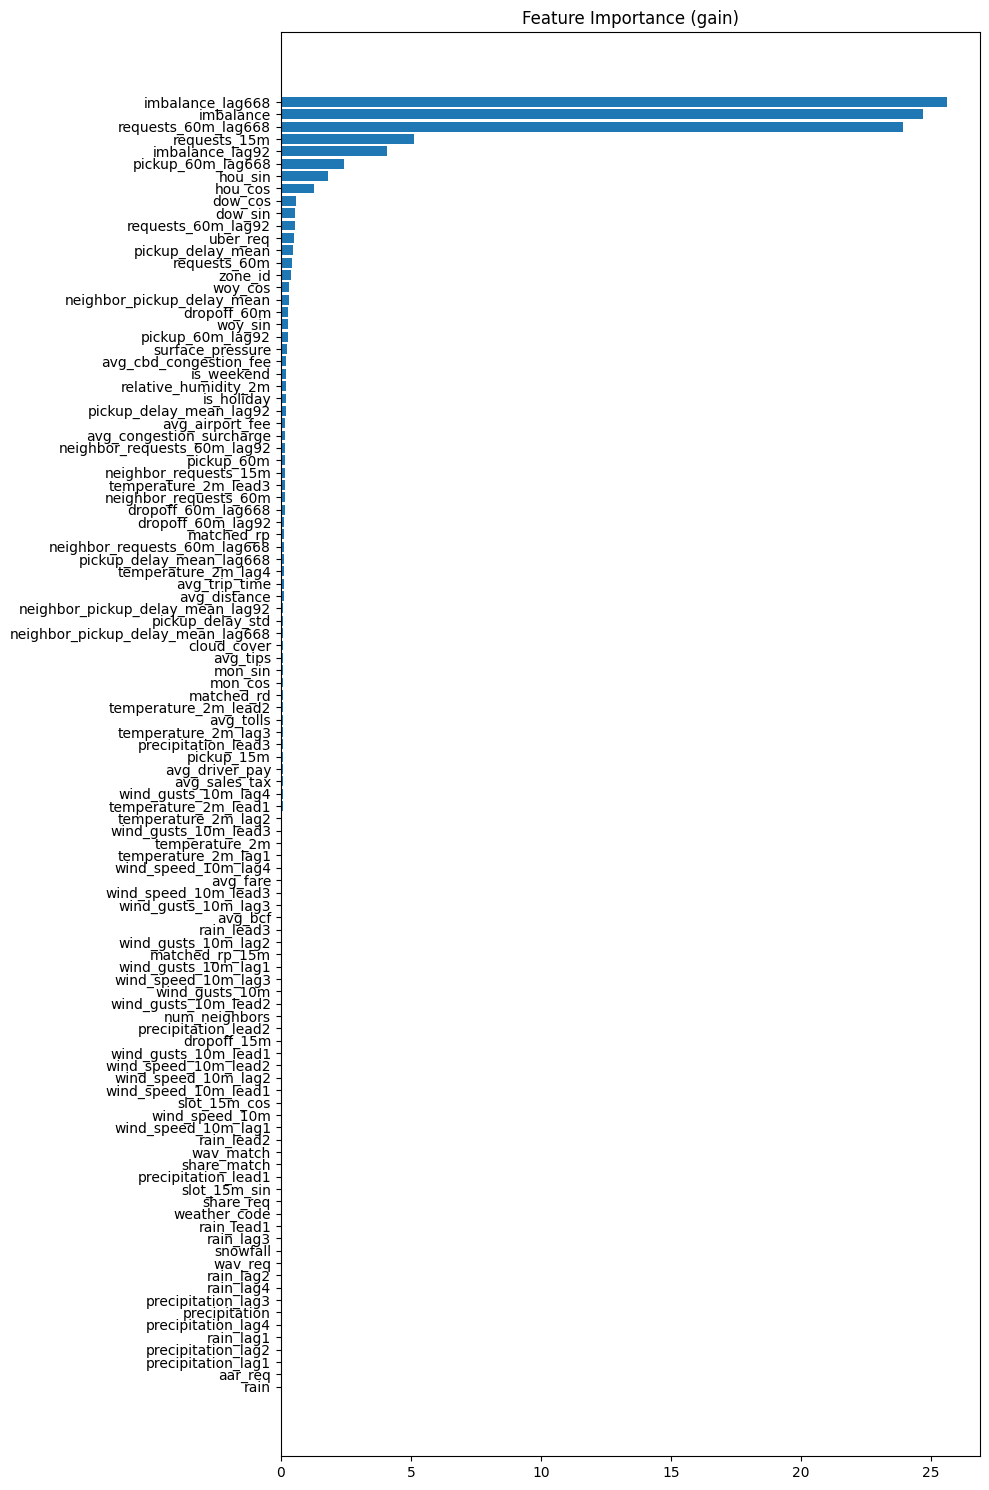

In [2]:
import matplotlib.pyplot as plt

fi_top = fi.head(137)

plt.figure(figsize=(10, 15))
plt.barh(fi_top["feature"], fi_top["importance_pct"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (gain)")
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

import lightgbm as lgb


# =========================
# 1. CONFIG
# =========================
DATA_PATH = r"C:\D\nam4_ki2\BigData\datasets\train_data\part-00038-25c10afb-a801-4eb0-9e0b-71aafa8c6c1d-c000.snappy.parquet"
TARGET_COL = "label_6class"


# =========================
# 2. LOAD DATA
# =========================
def load_data(path):
    df = pd.read_parquet(path)

    X = df.drop(columns=[TARGET_COL,"window_end"])
    y = df[TARGET_COL]

    return X, y

# =========================
# 4. PREDICT
# =========================
def predict(model, X):
    # LightGBM trả về xác suất cho từng class
    y_prob = model.predict(X)

    # lấy class có xác suất cao nhất
    y_pred = np.argmax(y_prob, axis=1)

    return y_pred, y_prob


# =========================
# 5. EVALUATE
# =========================
def evaluate(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)

    f1_macro = f1_score(y_true, y_pred, average="macro")
    f1_weighted = f1_score(y_true, y_pred, average="weighted")

    precision_macro = precision_score(y_true, y_pred, average="macro")
    recall_macro = recall_score(y_true, y_pred, average="macro")

    print("===== METRICS =====")
    print(f"Accuracy       : {acc:.4f}")
    print(f"F1 (macro)     : {f1_macro:.4f}")
    print(f"F1 (weighted)  : {f1_weighted:.4f}")
    print(f"Precision      : {precision_macro:.4f}")
    print(f"Recall         : {recall_macro:.4f}")

    print("\n===== CLASSIFICATION REPORT =====")
    print(classification_report(y_true, y_pred))

    print("\n===== CONFUSION MATRIX =====")
    print(confusion_matrix(y_true, y_pred))


# =========================
# 6. MAIN
# =========================
def main():
    print("Loading data...")
    X, y = load_data(DATA_PATH)

    print("Loading model...")
    print("Predicting...")
    y_pred, _ = predict(model, X)

    print("Evaluating...")
    evaluate(y, y_pred)


if __name__ == "__main__":
    main()

Loading data...
Loading model...
Predicting...
Evaluating...
===== METRICS =====
Accuracy       : 0.7677
F1 (macro)     : 0.7427
F1 (weighted)  : 0.7682
Precision      : 0.7385
Recall         : 0.7495

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.60      0.63      0.62      3847
           1       0.70      0.82      0.75     41243
           2       0.79      0.75      0.77    108268
           3       0.80      0.78      0.79    114482
           4       0.71      0.76      0.74     45293
           5       0.83      0.76      0.80     18175

    accuracy                           0.77    331308
   macro avg       0.74      0.75      0.74    331308
weighted avg       0.77      0.77      0.77    331308


===== CONFUSION MATRIX =====
[[ 2421  1424     2     0     0     0]
 [ 1598 33744  5893     8     0     0]
 [    7 12967 80854 14407    29     4]
 [    0   123 15391 88957  9969    42]
 [    0     5   154  7878 34469  27